In [1]:
print("Hello World !")

Hello World !


# DeepLearning Assignment Number 01
## Problem Statement
Install and configure TensorFlow/Keras in Google Colab. Perform data preprocessing, normalization, train-test splitting, and data visualization on a sample dataset.

## Algorithm
1.	Start the program.
2.	Import the required libraries:
- TensorFlow
- Keras
- NumPy
- Matplotlib
3.	Load the MNIST Handwritten Digits dataset.
4.	Separate the dataset into:
- Training data
- Testing data
5.	Display the dataset information:
- Number of training images
- Number of testing images
- Shape of images
- Sample labels
6.	Visualize sample handwritten digit images.
7.	Normalize the pixel values by dividing each pixel value by 255.
8.	Create a Sequential Neural Network consisting of:
- Flatten Layer
- Hidden Layer 1 (128 neurons, ReLU activation)
- Hidden Layer 2 (64 neurons, ReLU activation)
- Output Layer (10 neurons, Softmax activation)
9.	Compile the model using:
- Adam Optimizer
- Sparse Categorical Crossentropy Loss Function
- Accuracy Metric
10.	Train the model using the training dataset with a validation split.
11.	Evaluate the trained model using the testing dataset.
12.	Predict the class labels for sample test images.
13.	Display the predicted and actual digit labels.
14.	Save the trained model in .keras format.
15.	Stop the program.


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

In [5]:
print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

TensorFlow Version: 2.20.0
Keras Version: 3.13.2


In [6]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [7]:
print("Number of Training Images :", len(x_train))
print("Number of Testing Images  :", len(x_test))

print("\nTraining Image Shape :", x_train.shape)
print("Testing Image Shape  :", x_test.shape)

print("\nSample Labels:")
print(y_train[:10])

#Dataset information

Number of Training Images : 60000
Number of Testing Images  : 10000

Training Image Shape : (60000, 28, 28)
Testing Image Shape  : (10000, 28, 28)

Sample Labels:
[5 0 4 1 9 2 1 3 1 4]


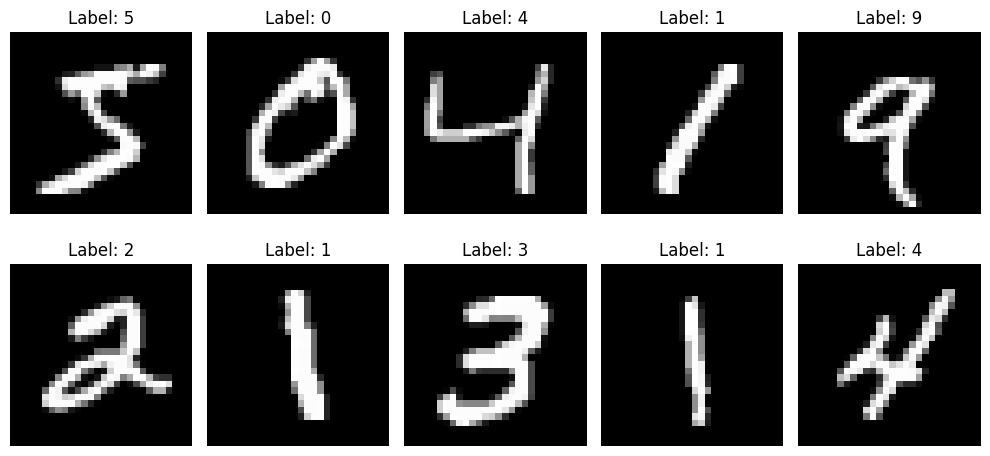

In [8]:
plt.figure(figsize=(10,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title("Label: {}".format(y_train[i]))
  plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Normalization Completed!")

print("Pixel Value Range:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Normalization Completed!
Pixel Value Range:
Minimum: 0.0
Maximum: 1.0


In [10]:
model = keras.Sequential([
  keras.layers.Flatten(input_shape=(28,28)),
  keras.layers.Dense(128, activation='relu'),
  keras.layers.Dense(64, activation='relu'),
  keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [12]:
history = model.fit(
  x_train,
  y_train,
  epochs=5,
  validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9197 - loss: 0.2714 - val_accuracy: 0.9575 - val_loss: 0.1448
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9654 - loss: 0.1139 - val_accuracy: 0.9697 - val_loss: 0.1046
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9768 - loss: 0.0750 - val_accuracy: 0.9713 - val_loss: 0.0942
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9818 - loss: 0.0577 - val_accuracy: 0.9747 - val_loss: 0.0884
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9856 - loss: 0.0435 - val_accuracy: 0.9744 - val_loss: 0.0955


In [13]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0820

Test Loss: 0.08198972791433334
Test Accuracy: 0.9763000011444092


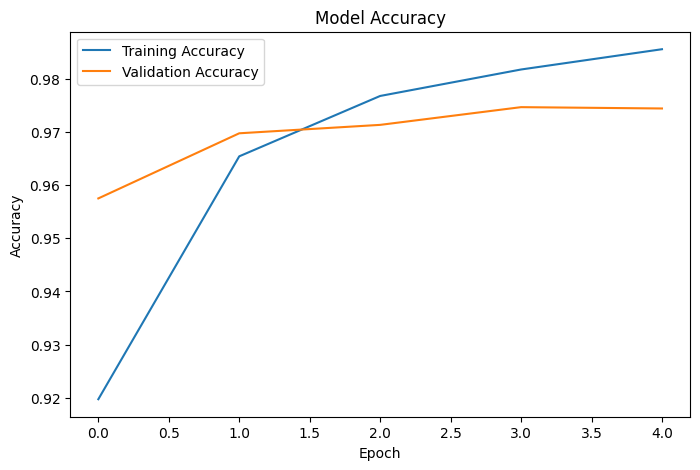

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

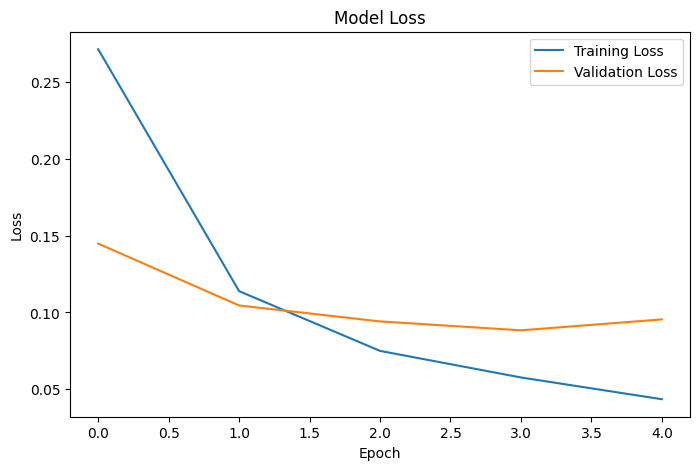

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [16]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


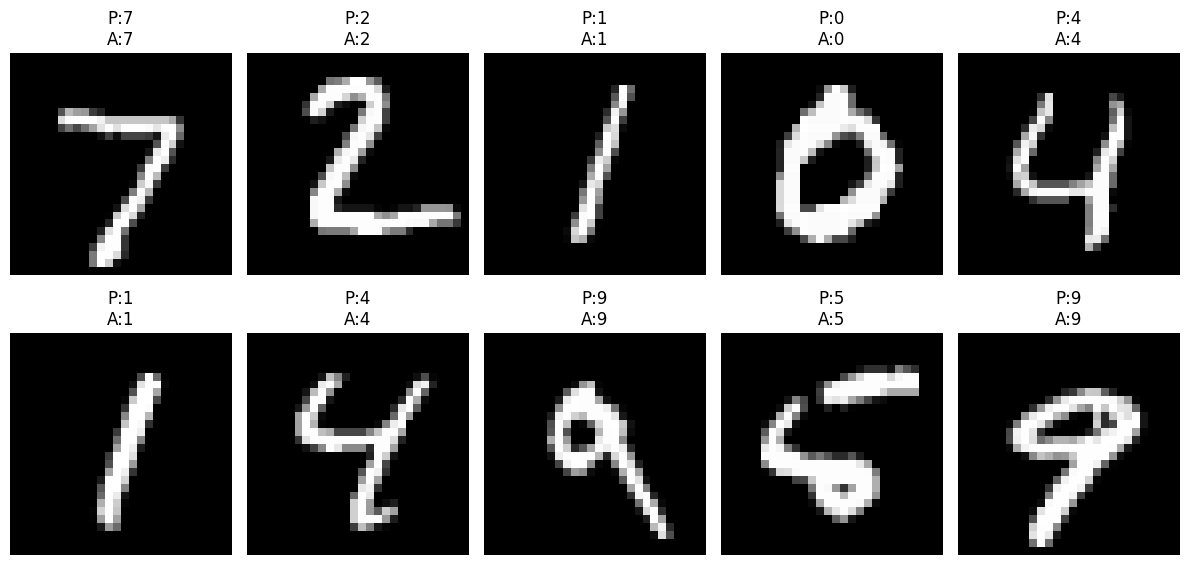

In [17]:
plt.figure(figsize=(12,6))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[i], cmap='gray')
  plt.title(f"P:{predicted_labels[i]}\nA:{y_test[i]}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
model.save("mnist_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!
